<a href="https://colab.research.google.com/github/Bbirublu/PCD/blob/main/Tugas5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-image

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import structural_similarity as ssim
import time

In [3]:
from google.colab import files
uploaded = files.upload()

Saving citra1.jpg to citra1.jpg


(np.float64(-0.5), np.float64(3999.5), np.float64(2999.5), np.float64(-0.5))

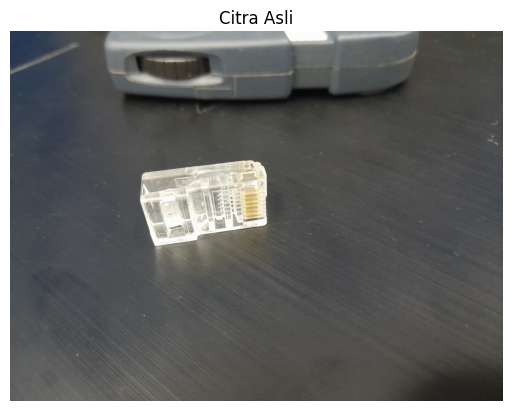

In [4]:
img = cv2.imread('citra1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Citra Asli")
plt.axis('off')

In [6]:
def add_gaussian_noise(image):
    noise = np.random.normal(0, 25, image.shape).astype(np.uint8)
    return cv2.add(image, noise)

In [7]:
def add_salt_pepper(image, prob=0.02):
    noisy = image.copy()
    rnd = np.random.rand(*image.shape[:2])

    noisy[rnd < prob] = 0
    noisy[rnd > 1 - prob] = 255

    return noisy

In [8]:
def add_speckle(image):
    noise = np.random.randn(*image.shape)
    noisy = image + image * noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

In [9]:
gaussian = add_gaussian_noise(img)
sp = add_salt_pepper(img)
speckle = add_speckle(img)

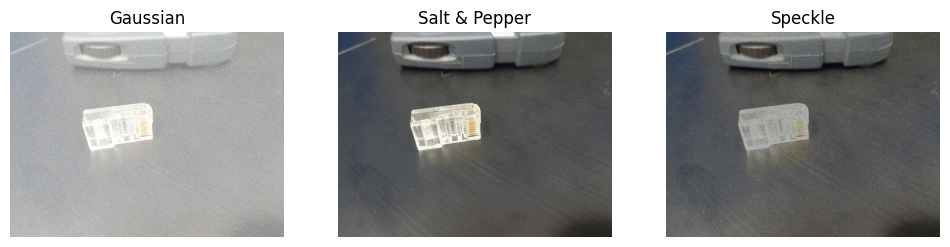

In [10]:
titles = ['Gaussian', 'Salt & Pepper', 'Speckle']
images = [gaussian, sp, speckle]

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

In [11]:
def mean_filter(image, k):
    return cv2.blur(image, (k, k))

def gaussian_filter(image, k, sigma):
    return cv2.GaussianBlur(image, (k, k), sigma)

def median_filter(image, k):
    return cv2.medianBlur(image, k)

def max_filter(image, k):
    return cv2.dilate(image, np.ones((k,k), np.uint8))

In [12]:
def evaluate(original, filtered):
    start = time.time()

    p = psnr(original, filtered)
    m = mse(original, filtered)
    s = ssim(original, filtered, channel_axis=2)

    end = time.time()

    return p, m, s, (end-start)

In [13]:
results = []

filters = [
    ("Mean 3x3", mean_filter(gaussian, 3)),
    ("Mean 5x5", mean_filter(gaussian, 5)),
    ("Gaussian σ1", gaussian_filter(gaussian, 5, 1)),
    ("Gaussian σ2", gaussian_filter(gaussian, 5, 2)),
    ("Median 3x3", median_filter(gaussian, 3)),
    ("Median 5x5", median_filter(gaussian, 5)),
    ("Max 3x3", max_filter(gaussian, 3)),
]

for name, img_f in filters:
    p, m, s, t = evaluate(img, img_f)
    results.append([name, p, m, s, t])

In [14]:
for r in results:
    print(f"{r[0]} | PSNR: {r[1]:.2f} | MSE: {r[2]:.2f} | SSIM: {r[3]:.3f} | Time: {r[4]:.5f}")

Mean 3x3 | PSNR: 8.49 | MSE: 9214.22 | SSIM: 0.113 | Time: 8.51545
Mean 5x5 | PSNR: 8.69 | MSE: 8794.16 | SSIM: 0.240 | Time: 7.30020
Gaussian σ1 | PSNR: 8.57 | MSE: 9047.74 | SSIM: 0.143 | Time: 7.75743
Gaussian σ2 | PSNR: 8.68 | MSE: 8812.74 | SSIM: 0.236 | Time: 7.59136
Median 3x3 | PSNR: 6.63 | MSE: 14129.55 | SSIM: 0.036 | Time: 7.59286
Median 5x5 | PSNR: 6.78 | MSE: 13640.02 | SSIM: 0.046 | Time: 7.73583
Max 3x3 | PSNR: 3.46 | MSE: 29330.27 | SSIM: 0.462 | Time: 7.50010


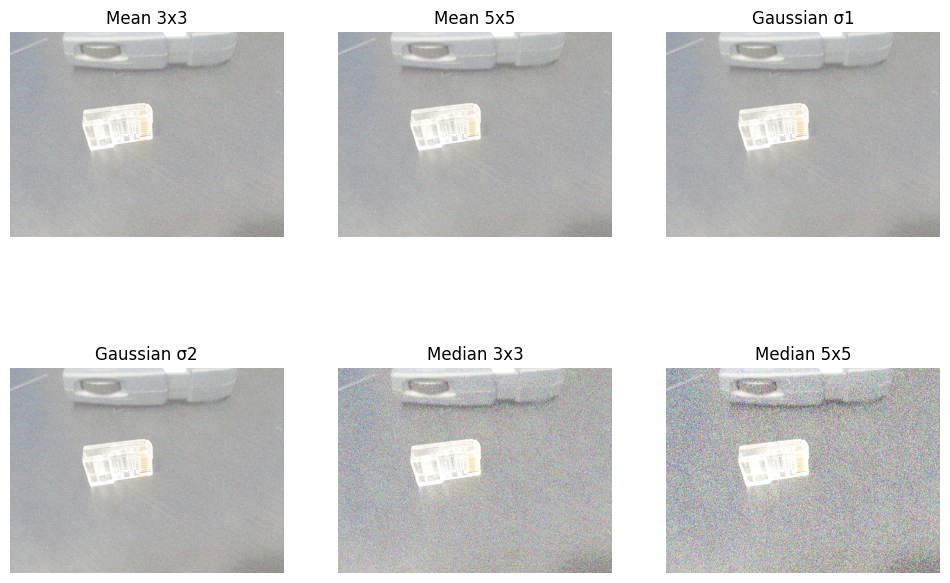

In [15]:
plt.figure(figsize=(12,8))

for i, (name, img_f) in enumerate(filters[:6]):
    plt.subplot(2,3,i+1)
    plt.imshow(img_f)
    plt.title(name)
    plt.axis('off')